##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells.

# EXAM03: Data Science Group Assignment - Iteration 3

**Group name:** [Be Right Back]

**Student names & numbers:**
* [Rick de Cuijper] - [Student no.100097]
* [Bart Geijtenbeek] - [Student no.97543]
* [Boaz Vaneveld] - [Student no.101529]

---

## 0. Iteration setup

**Import libraries**

In [27]:
# CODE CELL: Import the necessary libraries for this iteration (including scikit-learn models and metrics)
import pandas as pd;
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


**Load & Merge dataset(s)**

In [2]:
# CODE CELL: Import the necessary datasets for this iteration.
# Load your fully cleaned dataset from Iteration 2 AND the new performance logs.
# Merge them together based on the Ship_ID

df_ships2 = pd.read_csv("ships_inventory_iter1_leftJoin_iter2_clean.csv")
df_ships2.head(5)

,Unnamed: 0.1,Unnamed: 0,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Model_Cycle_Clean,Galactic_Credits_Clean,Is_Outlier,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class,Model_Cycle_Bin,Missing,Reactor_Power_Clean,Propulsion_Type_Clean,Possible_Overclocked_reactor,Predicted_Hull_Integrity
0,0,0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,7505.0,4950,False,Critical,40.0,Ion Drive,Shuttle,"(7503.0, 7507.0]",False,40.0,Ion Drive,False,Critical
1,1,1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,7518.0,18999,False,Pristine,120.0,Solar Sail,Shuttle,"(7517.0, 7519.0]",False,120.0,Solar Sail,False,Pristine
2,2,2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,7486.0,4000,False,Critical,40.0,Ion Drive,Shuttle,"(7399.999, 7503.0]",False,40.0,Ion Drive,False,Critical
3,3,3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,7511.0,6495,False,Pristine,40.0,Graviton Beam,Shuttle,"(7510.0, 7512.0]",False,40.0,Graviton Beam,False,Operational
4,4,4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,7499.0,3995,False,Critical,40.0,Hyperdrive,Shuttle,"(7399.999, 7503.0]",False,40.0,Hyperdrive,False,Critical


In [3]:
df_ships3 = pd.read_csv("ship_performance_logs_iter3.csv")
df_ships3.head(5)

,Ship_ID,Lightyears_Traveled,Registration_Status
0,7316814884,40.610676,Refurbished
1,7316814758,66.153551,Imperial Certified
2,7316814989,10.844388,Refurbished
3,7316743432,29.576094,Refurbished
4,7316356412,122.111671,Refurbished


In [4]:
#left join to keep previous data intact without introducing more unknown data
df_merged2 = df_ships2.merge(df_ships3, left_on='Ship_ID', right_on='Ship_ID', how='left')
df_merged2.head()

,Unnamed: 0.1,Unnamed: 0,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Model_Cycle_Clean,Galactic_Credits_Clean,Is_Outlier,...,Propulsion_Type,Ship_Class,Model_Cycle_Bin,Missing,Reactor_Power_Clean,Propulsion_Type_Clean,Possible_Overclocked_reactor,Predicted_Hull_Integrity,Lightyears_Traveled,Registration_Status
0,0,0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,7505.0,4950,False,...,Ion Drive,Shuttle,"(7503.0, 7507.0]",False,40.0,Ion Drive,False,Critical,104.554402,Smuggler Logic
1,1,1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,7518.0,18999,False,...,Solar Sail,Shuttle,"(7517.0, 7519.0]",False,120.0,Solar Sail,False,Pristine,21.540154,Imperial Certified
2,2,2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,7486.0,4000,False,...,Ion Drive,Shuttle,"(7399.999, 7503.0]",False,40.0,Ion Drive,False,Critical,87.313033,Imperial Certified
3,3,3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,7511.0,6495,False,...,Graviton Beam,Shuttle,"(7510.0, 7512.0]",False,40.0,Graviton Beam,False,Operational,144.885019,Imperial Certified
4,4,4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,7499.0,3995,False,...,Hyperdrive,Shuttle,"(7399.999, 7503.0]",False,40.0,Hyperdrive,False,Critical,124.394203,Smuggler Logic


---

## 1. Business Understanding

**Situation description**

Nebula Brokerage is moving beyond the simple rule-based and statistical models from earlier iterations because those approaches cannot adequately capture the complexity of the data. The relationships between feature are nonlinear and interdependent. As a result, the previous model are underfit to the total and compete datasat (iter 1 2 3) and fail to generalize well to new data(iter3). A machine learning approach allows the company to better model these complex patterns and improve prediction quality.

**Business objective(s)**

The goal is to build an AI-driven pipeline that predicts both Galactic Credits (price) and Condition. This adds business value by:

- Improving pricing accuracy, leading to better profit margins and competitiveness
- Standardizing condition assessment, reducing subjectivity and human error
- Enabling faster and more scalable decision-making

**Data mining goal(s)**

There are two modeling tasks in this iteration:

- Regression task: Predict Galactic Credits (The price)
- Classification task: Predict Condition (critical, operational, pristine)

**Success criteria**

The new models MUST outpreform the previos iteration 1 and 2 by less MAE, RMSE and a better accuraty > 85% and a better R*2 score.

The model achives acceptable scores on the train and test sets: less he 20% difference in MAE and RMSE

---

## 2. Data Understanding

**Data exploration (New Features)**

*Show the summary statistics for the newly merged data. Focus your description on the new variables: Lightyears_Traveled and Registration_Status.*

In [5]:
df_merged2.info()
df_merged2.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368314 entries, 0 to 368313
Data columns (total 22 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Unnamed: 0.1                  368314 non-null  int64  
 1   Unnamed: 0                    368314 non-null  int64  
 2   Ship_ID                       368314 non-null  int64  
 3   Galactic_Credits              368314 non-null  int64  
 4   Model_Cycle                   360916 non-null  float64
 5   Ship_Manufacturer             368314 non-null  object 
 6   Sector                        368314 non-null  object 
 7   Model_Cycle_Clean             368314 non-null  float64
 8   Galactic_Credits_Clean        368314 non-null  int64  
 9   Is_Outlier                    368314 non-null  bool   
 10  Hull_Integrity                368314 non-null  object 
 11  Reactor_Power                 338876 non-null  float64
 12  Propulsion_Type               311704 non-nul

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,368314.0,1.841565e+05,1.063232e+05,0.000000e+00,9.207825e+04,1.841565e+05,2.762348e+05,3.683130e+05
Unnamed: 0,368314.0,1.843607e+05,1.064758e+05,0.000000e+00,9.214325e+04,1.843375e+05,2.765768e+05,3.688130e+05
Ship_ID,368314.0,7.311484e+09,4.381194e+06,7.301583e+09,7.308103e+09,7.312604e+09,7.315244e+09,7.317101e+09
Galactic_Credits,368314.0,1.945424e+04,1.554266e+04,5.010000e+02,7.950000e+03,1.599000e+04,2.799000e+04,7.777770e+05
Model_Cycle,360916.0,7.511264e+03,9.079721e+00,7.400000e+03,7.508000e+03,7.513000e+03,7.517000e+03,7.522000e+03
Model_Cycle_Clean,368314.0,7.511299e+03,8.991369e+00,7.400000e+03,7.508000e+03,7.513000e+03,7.517000e+03,7.522000e+03
Galactic_Credits_Clean,368314.0,1.930990e+04,1.436495e+04,5.010000e+02,7.950000e+03,1.599000e+04,2.799000e+04,7.800000e+04
Reactor_Power,338876.0,7.159256e+01,4.464415e+01,3.000000e+01,4.000000e+01,6.000000e+01,8.000000e+01,3.600000e+02
Reactor_Power_Clean,368314.0,7.049083e+01,4.319317e+01,3.000000e+01,4.000000e+01,6.000000e+01,8.000000e+01,3.600000e+02
Lightyears_Traveled,361069.0,1.048270e+02,8.894300e+01,0.000000e+00,3.060655e+01,8.547708e+01,1.575455e+02,1.559606e+03


In [6]:
cols = ['Lightyears_Traveled', 'Registration_Status']

missing_count = df_merged2[cols].isnull().sum()

# Percentage of missing values
missing_percentage = (df_merged2[cols].isnull().sum() / len(df_merged2)) * 100

# combine into one table
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing (%)': missing_percentage
})

print(missing_summary)

                     Missing Count  Missing (%)
Lightyears_Traveled           7245     1.967072
Registration_Status           7245     1.967072


2 new datacollums have been added: Lightyears_Traveled showing the odometer of the ship in lightyears, and Registration_Status showing the status of the ship according to the imperial registry showing if a ship has a criminal background posibly leading to legal problems for the sale. 

**Visualizations and patterns**
*Create visualizations to discover the impact of the new features.

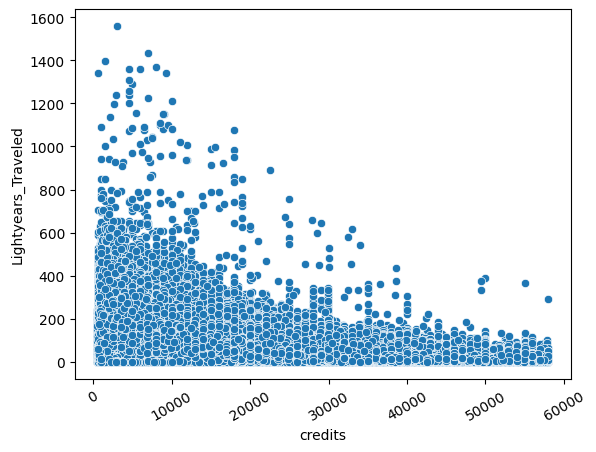

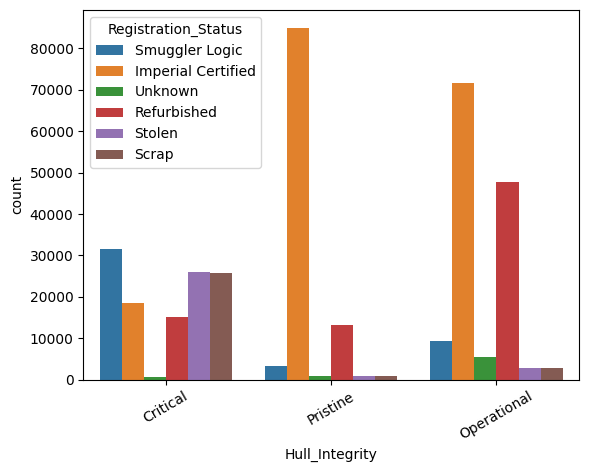

In [7]:
sns.scatterplot(data=df_merged2, x='Galactic_Credits_Clean', y='Lightyears_Traveled')
plt.xticks(rotation=30)
plt.xlabel("credits")
plt.show()
sns.countplot(data=df_merged2, x="Hull_Integrity", hue="Registration_Status")
plt.xticks(rotation=30)
plt.show()


**Data insights and data quality**

* **Insights:** Does high mileage lower the price? Does a 'Stolen' status correlate with critical hull condition?
* **Quality issues:** Document any missing values and other issues

there is a downwards corelation between lightyears traveled and credits, above a surtain point the dencety of data decreases severely, posibly pointing to overpriced vehicles.

critical vehicles are significantly more likely to be involved in criminal activity, while pristene is almost never involved in such businesses.


the number of amount of missing data in the new rows is low, so it won't skew the data too much without creating bias.

---

## 3. Data Preparation

**Cleaning and preprocessing**

*Describe and justify how you resolve your data errors.*

In [8]:
# lightyears get filled with the median, because it is the most likely to be closer to the correct number
df_merged2['Lightyears_Traveled'] = df_merged2['Lightyears_Traveled'].fillna(df_merged2['Lightyears_Traveled'].median())

# if hull integrity is prisine or operational it is safe to asume the vehicle is clean
df_merged2.loc[
    (df_merged2['Registration_Status'].isna()) &
    (df_merged2['Hull_Integrity'].isin(['Pristine', 'Operational'])),
    'Registration_Status'
] = 'Imperial_Certified'

# else it is unsurtain what the vehicle is so it is unknown due to the balance of critical vehicles
df_merged2['Registration_Status'] = df_merged2['Registration_Status'].fillna('Unknown')

**Feature encoding**

*Describe how you converted your categorical columns into a format the model can use.*

In [22]:
#adds new collum that puts Hull_Integrity in a numeric value from critical = 0 to pristine = 2,
#so the higher the vallue, the better the condition
df_merged2['Hull_Integrity_Numerical'] = df_merged2['Hull_Integrity'].map({
    'Critical': 0,
    'Operational': 1,
    'Pristine': 2
})

#adds new collum that puts Registration_Status in a numeric value from Scrap or Unknown = 0 to Imperial Certified = 3,
#so the higher the vallue, the better the condition
df_merged2['Registration_Status_Numerical'] = df_merged2['Registration_Status'].map({
    'Scrap': 0,
    'Unknown': 0,
    'Stolen': 1,
    'Smuggler Logic': 1,
    'Refurbished': 2,
    'Imperial Certified': 3,
    'Imperial_Certified': 3
})
df_merged2.head(10)

,Unnamed: 0.1,Unnamed: 0,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Model_Cycle_Clean,Galactic_Credits_Clean,Is_Outlier,...,Model_Cycle_Bin,Missing,Reactor_Power_Clean,Propulsion_Type_Clean,Possible_Overclocked_reactor,Predicted_Hull_Integrity,Lightyears_Traveled,Registration_Status,Hull_Integrity_Numerical,Registration_Status_Numerical
0,0,0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,7505.0,4950,False,...,"(7503.0, 7507.0]",False,40.0,Ion Drive,False,Critical,104.554402,Smuggler Logic,0,1
1,1,1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,7518.0,18999,False,...,"(7517.0, 7519.0]",False,120.0,Solar Sail,False,Pristine,21.540154,Imperial Certified,2,3
2,2,2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,7486.0,4000,False,...,"(7399.999, 7503.0]",False,40.0,Ion Drive,False,Critical,87.313033,Imperial Certified,0,3
3,3,3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,7511.0,6495,False,...,"(7510.0, 7512.0]",False,40.0,Graviton Beam,False,Operational,144.885019,Imperial Certified,2,3
4,4,4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,7499.0,3995,False,...,"(7399.999, 7503.0]",False,40.0,Hyperdrive,False,Critical,124.394203,Smuggler Logic,0,1
5,5,5,7313451637,25990,7519.0,Republic Aerospace,Calodan Expanse,7519.0,25990,False,...,"(7517.0, 7519.0]",True,80.0,Ion Drive,False,Pristine,11.419077,Imperial Certified,2,3
6,6,6,7316546982,4000,7509.0,General Mining Corp,Mimban Swamp,7509.0,4000,False,...,"(7507.0, 7510.0]",True,60.0,Ion Drive,False,Critical,279.210053,Smuggler Logic,0,1
7,7,7,7311754900,7999,7508.0,Hondo Systems,Mon Cala Ocean Worlds,7508.0,7999,False,...,"(7507.0, 7510.0]",True,60.0,Solar Sail,False,Critical,76.050568,Imperial Certified,0,3
8,8,8,7313137564,5999,7497.0,Bayerische Motoren Wormhole,Iridonia Belt,7497.0,5999,False,...,"(7399.999, 7503.0]",False,60.0,Ion Drive,False,Critical,210.427682,Unknown,0,0
9,9,9,7302916705,58995,7517.0,General Mining Corp,Wroona Spaceport,7517.0,58995,False,...,"(7516.0, 7517.0]",False,80.0,Nuclear Pulse,False,Pristine,85.477075,Imperial_Certified,1,3


---

## 4. Modeling: Task A

**Regression setup**

*Set up a [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model to predict `Galactic_Credits`. Make sure to split your data into training and testing sets.*

In [28]:
# CODE CELL: Train-Test split & train the Linear Regression model
feature = df_merged2[[
  "Ship_ID", "Model_Cycle_Clean", "Reactor_Power_Clean", "Lightyears_Traveled", "Hull_Integrity_Numerical", "Registration_Status_Numerical"
]] #model kan alleen numerieke waarders krijgen
target = df_merged2["Galactic_Credits"]

X_train, X_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Testing and performance (Regression)**

*Calculate the MAE, RMSE and R2 score. Create a plot showing Actual vs. Predicted prices to visually verify model performance.*

In [29]:
# CODE CELL: Evaluate the rgression model and plot Actual vs Predicted

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 7540.3910165170455
RMSE: 12289.015644235724
R2: 0.3806357062799258


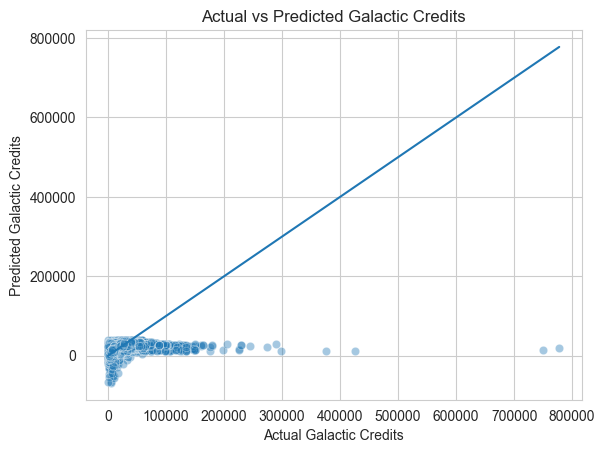

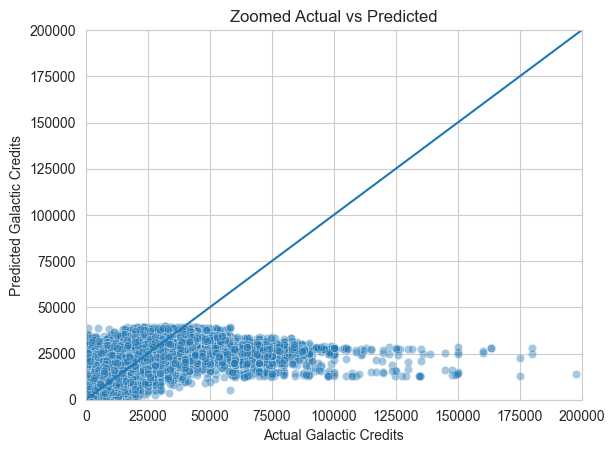

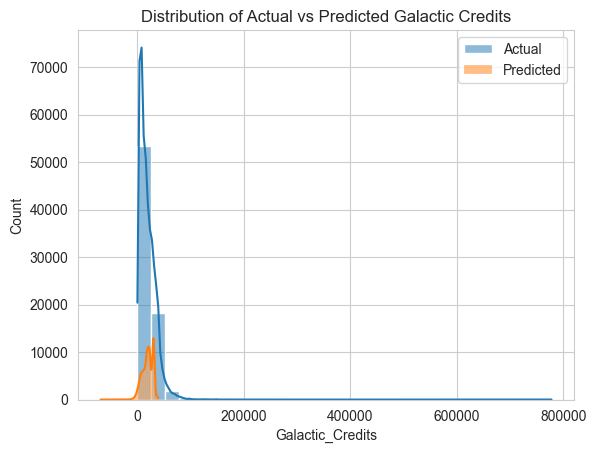

In [47]:
#graph1 
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Galactic Credits")
plt.ylabel("Predicted Galactic Credits")
plt.title("Actual vs Predicted Galactic Credits")

plt.show()

#graph2
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlim(0, 200000)
plt.ylim(0, 200000)

plt.xlabel("Actual Galactic Credits")
plt.ylabel("Predicted Galactic Credits")
plt.title("Zoomed Actual vs Predicted")

plt.show()

#graph3
sns.histplot(y_test, bins=30, kde=True, label="Actual")
sns.histplot(y_pred, bins=30, kde=True, label="Predicted")

plt.legend()
plt.title("Distribution of Actual vs Predicted Galactic Credits")

plt.show()

---

## 5. Modeling: Task B

**Classification setup**

*Set up a [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to predict `Hull_Integrity`. Split the data into training and testing sets.*

In [7]:
# CODE CELL: Train-Test split & train the Decision Tree model.

**Testing and performance (classification)**

*Calculate the Accuracy and plot a confusion matrix. Explain what the matrix tells you about the predictions.*

In [6]:
# CODE CELL: Evaluate your classification model (check ou tthe metrics, include a confusion matrix)

---

## 6. Evaluation

**Assessment against success criteria** 

*Compare your models to the baselines:*
* *Are thr scores of this regression model better than Iteration 1? Why?*
* *Are the scores of the decision tree better than your manual rules from Iteration 2? Why?*

**Key findings and limitations**

*What are the final conclusions? Should Nebula Brokerage deploy these models? What are the remaining limitations?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset.

---

## 7. Personal Contribution

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Rick de Cuijper | *Contribution description* | *Personal lessons learned this iteration* |
| Boaz Vaneveld | *Contribution description* | *Personal lessons learned this iteration* |
| Bart Geijtenbeek | imported csv's, wrote data understanding, wrote data prep | *Personal lessons learned this iteration* |